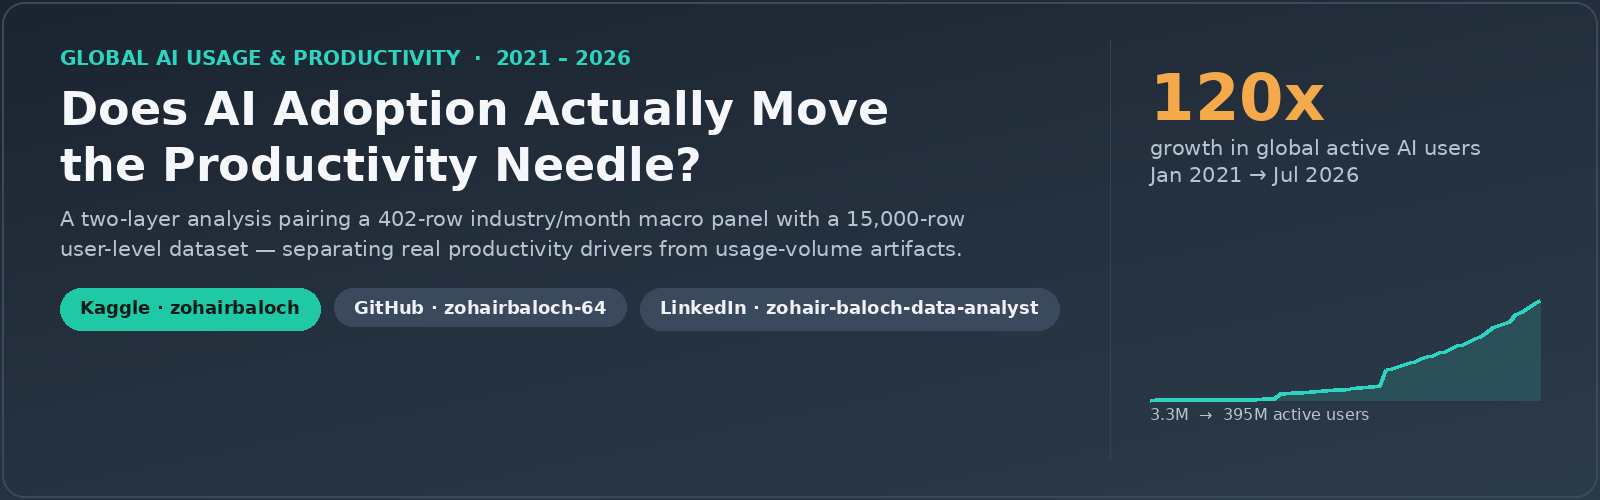

### Contents
1. [Plan &mdash; Business Context &amp; Questions](#plan)
2. [Analyze &mdash; Loading &amp; Data Quality](#analyze)
3. [Macro Trends 2021&ndash;2026 (Industry Panel)](#macro)
4. [User-Level Patterns (15K Individuals)](#user)
5. [Construct &mdash; Modeling Productivity Gain](#construct)
6. [Execute &mdash; Findings, SHAP &amp; Recommendations](#execute)

<a id="plan"></a>
## 1. Plan

**Business context.** Two datasets describe the same phenomenon at different resolutions:

| Dataset | Grain | Rows | Span |
|---|---|---|---|
| `ai_adoption_productivity_2021_2026.csv` | Industry &times; Month | 402 | Jan 2021 &ndash; Jul 2026 |
| `user_level_ai_adoption.csv` | Individual user | 15,000 | Adopted 2021 &ndash; 2026 |

**Questions this notebook answers:**
- How fast has AI usage actually grown since 2021, and which industries are ahead?
- At the individual level, what actually predicts a person's reported productivity gain &mdash; the tool they use, their industry, their experience, or simply how much they use it?
- Is there a difference between "usage volume predicts itself" and a genuine, actionable business signal?
- Which AI tools and job functions show the largest real-world productivity payoff?

Following the same standard I hold every notebook in this portfolio to: every metric reported here is checked for how it was derived, and if a model looks *too* good, that's treated as a signal to dig into the features, not a result to celebrate.

<a id="analyze"></a>
## 2. Analyze &mdash; Loading &amp; Data Quality

In [33]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# ---- palette: deliberately mid-tone -- not a stark black theme, not a plain white one ----
BG      = '#222b36'   # panel background (charcoal-slate, not pure black)
GRID    = '#3a4657'
TEXT    = '#e7ecf1'
SUBTEXT = '#9fb0c0'
TEAL    = '#2dd4bf'
AMBER   = '#f4a94a'
CORAL   = '#e8746b'
BLUE    = '#5b9bd5'
LILAC   = '#a48ee0'
PALETTE = [TEAL, AMBER, CORAL, BLUE, LILAC, '#7fd9c4', '#c9dc6c']

plotly_template = go.layout.Template()
plotly_template.layout = go.Layout(
    paper_bgcolor=BG, plot_bgcolor=BG,
    font=dict(family='Segoe UI, Arial', color=TEXT, size=12),
    title=dict(font=dict(size=17, color=TEXT)),
    xaxis=dict(gridcolor=GRID, zerolinecolor=GRID, color=SUBTEXT),
    yaxis=dict(gridcolor=GRID, zerolinecolor=GRID, color=SUBTEXT),
    legend=dict(bgcolor='rgba(0,0,0,0)'),
    colorway=PALETTE,
    margin=dict(t=70, l=60, r=30, b=50),
)
pio.templates['midtone'] = plotly_template
pio.templates.default = 'midtone'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': TEXT, 'text.color': TEXT,
    'xtick.color': SUBTEXT, 'ytick.color': SUBTEXT, 'grid.color': GRID,
    'axes.grid': True, 'grid.alpha': 0.5, 'font.family': 'DejaVu Sans',
    'axes.titlecolor': TEXT, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})

print('Environment ready.')

Environment ready.


In [34]:
macro = pd.read_csv('ai_adoption_productivity_2021_2026.csv')
users = pd.read_csv('user_level_ai_adoption.csv')

macro['YearMonth'] = pd.to_datetime(macro['YearMonth'])
users['Adoption_Date'] = pd.to_datetime(users['Adoption_Date'])

print('macro :', macro.shape)
print('users :', users.shape)
macro.head()

macro : (402, 6)
users : (15000, 10)


,YearMonth,Industry,Primary Use Case,Global Active Users (Millions),Average Tokens/User/Day,Productivity Gain (%)
0,2021-01-01,Software Development,Code Generation & Debugging,0.49,5248,4.9
1,2021-01-01,Marketing & Content,Copywriting & SEO,1.24,2141,9.7
2,2021-01-01,Customer Support,Automated Chatbots & Triage,0.83,3206,15.5
3,2021-01-01,Healthcare,Medical Records & Diagnostics Assistance,0.10,937,1.9
4,2021-01-01,Education,Lesson Planning & Tutoring,0.39,1594,7.6


In [35]:
users.head()

,User_ID,Industry,Job_Role,Location,Experience_Years,Primary_AI_Tool,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent,Adoption_Date
0,USR-690F519F,Software Development,Software Engineer,Europe,13,ChatGPT (OpenAI),10640,2,19.3,2023-02-28
1,USR-72A07ABB,Software Development,Software Engineer,North America,9,Claude (Anthropic),8535,1,5.0,2023-08-17
2,USR-CBCEAA19,Finance,Accountant,Asia-Pacific,21,Claude (Anthropic),9585,1,13.4,2023-11-02
3,USR-03B7DC34,Healthcare,Clinical Admin,North America,20,Perplexity,7094,2,9.9,2025-06-06
4,USR-CA8308D1,Marketing,Social Media Manager,Asia-Pacific,14,ChatGPT (OpenAI),9277,1,12.8,2023-04-03


**Data quality checks.** Before drawing any conclusions, I check for nulls, duplicates, out-of-range values, and &mdash; the check that most often surfaces problems in these public datasets &mdash; whether the categorical taxonomies actually line up *between* the two files.

In [36]:
print('--- Nulls ---')
print('macro:', macro.isnull().sum().sum(), ' | users:', users.isnull().sum().sum())

print('\n--- Duplicate rows ---')
print('macro:', macro.duplicated().sum(), ' | users:', users.duplicated().sum(), ' | duplicate User_IDs:', users['User_ID'].duplicated().sum())

print('\n--- Date ranges ---')
print('macro   :', macro['YearMonth'].min().date(), '->', macro['YearMonth'].max().date())
print('users   :', users['Adoption_Date'].min().date(), '->', users['Adoption_Date'].max().date())

print('\n--- Value ranges ---')
print('Experience_Years         :', users['Experience_Years'].min(), '-', users['Experience_Years'].max())
print('Productivity_Gain_Percent:', round(users['Productivity_Gain_Percent'].min(),1), '-', round(users['Productivity_Gain_Percent'].max(),1))
print('Daily_Token_Usage        :', users['Daily_Token_Usage'].min(), '-', users['Daily_Token_Usage'].max())

--- Nulls ---
macro: 0  | users: 0

--- Duplicate rows ---
macro: 0  | users: 0  | duplicate User_IDs: 0

--- Date ranges ---
macro   : 2021-01-01 -> 2026-07-01
users   : 2021-01-01 -> 2026-06-30

--- Value ranges ---
Experience_Years         : 1 - 25
Productivity_Gain_Percent: 0.3 - 84.9
Daily_Token_Usage        : 411 - 58989


No nulls, no duplicate rows, and no duplicate `User_ID`s &mdash; both files are clean on the surface. But look at the industry labels each file uses:

In [37]:
macro_industries = set(macro['Industry'].unique())
user_industries  = set(users['Industry'].unique())

print('Macro-panel industries :', sorted(macro_industries))
print('User-level industries  :', sorted(user_industries))
print()
print('In macro panel but NOT in user data :', macro_industries - user_industries)
print('In user data but NOT in macro panel :', user_industries - macro_industries)

Macro-panel industries : ['Customer Support', 'Education', 'Finance & Legal', 'Healthcare', 'Marketing & Content', 'Software Development']
User-level industries  : ['Creative & Design', 'Education', 'Finance', 'Healthcare', 'Marketing', 'Software Development']

In macro panel but NOT in user data : {'Marketing & Content', 'Customer Support', 'Finance & Legal'}
In user data but NOT in macro panel : {'Marketing', 'Creative & Design', 'Finance'}


**Finding:** the two files use *different industry taxonomies*. The macro panel bundles Finance and Legal together and has no standalone "Creative & Design" bucket; the user-level file splits Finance out on its own and adds Creative & Design, but has no separate Legal category. This means **the two datasets cannot be safely merged or cross-validated industry-to-industry** &mdash; each has to be analyzed on its own terms, and any industry-level comparison between them would silently mix populations. I'm flagging it here rather than merging anyway and hoping it averages out, since that's exactly the kind of silent mismatch that produces misleading joins.

I'll treat the two files as two independent lenses on the same story: the macro panel for the **shape of adoption over time**, and the user-level file for **what drives individual productivity outcomes**.

<a id="macro"></a>
## 3. Macro Trends 2021&ndash;2026 &mdash; The Industry Panel

### 3.1 How fast has global usage actually grown?

In [38]:
total_users = macro.groupby('YearMonth')['Global Active Users (Millions)'].sum().reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=total_users['YearMonth'], y=total_users['Global Active Users (Millions)'],
    mode='lines', line=dict(color=TEAL, width=3), fill='tozeroy',
    fillcolor='rgba(45,212,191,0.12)', name='Global active users'
))
fig.update_layout(
    title='Global Active AI Users, Summed Across Industries (2021 – 2026)',
    yaxis_title='Active users (millions)', xaxis_title=None, height=430, showlegend=False
)
fig.show()

start = total_users['Global Active Users (Millions)'].iloc[0]
end = total_users['Global Active Users (Millions)'].iloc[-1]
print(f'Jan 2021: {start:.2f}M active users  ->  Jul 2026: {end:.1f}M active users  ({end/start:,.0f}x growth)')

Jan 2021: 3.25M active users  ->  Jul 2026: 394.9M active users  (122x growth)


Global active users climbed from roughly **3.3M in January 2021 to 395M by July 2026** &mdash; about **120x** in five and a half years, with no visible plateau yet in this data. The curve is closer to compounding growth than a slowdown-and-saturate S-curve, at least through the window this dataset covers.

### 3.2 Which industries grew fastest &mdash; and which converted that growth into productivity?

In [39]:
first_month = macro['YearMonth'].min()
last_month = macro['YearMonth'].max()

start_df = macro[macro['YearMonth'] == first_month].groupby('Industry')['Global Active Users (Millions)'].sum()
end_df   = macro[macro['YearMonth'] == last_month].groupby('Industry')['Global Active Users (Millions)'].sum()
latest_prod = macro[macro['YearMonth'] == last_month].groupby('Industry')['Productivity Gain (%)'].mean()

growth = pd.DataFrame({'start_users': start_df, 'end_users': end_df, 'latest_productivity_gain': latest_prod})
growth['growth_multiple'] = growth['end_users'] / growth['start_users']
growth = growth.sort_values('growth_multiple', ascending=False)
growth

,start_users,end_users,latest_productivity_gain,growth_multiple
Industry,,,,
Education,0.39,103.97,46.3,266.589744
Software Development,0.49,74.51,68.4,152.061224
Customer Support,0.83,101.25,62.3,121.987952
Marketing & Content,1.24,99.47,54.5,80.217742
Finance & Legal,0.20,11.96,41.5,59.800000
Healthcare,0.10,3.74,37.0,37.400000


In [40]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=growth.index, y=growth['growth_multiple'],
    marker_color=PALETTE[:len(growth)], text=[f'{v:,.0f}x' for v in growth['growth_multiple']],
    textposition='outside', name='Growth multiple'
))
fig.update_layout(
    title='User Growth Multiple by Industry: Jan 2021 → Jul 2026',
    yaxis_title='Growth multiple (x)', height=440, showlegend=False
)
fig.show()

**Education grew the fastest (267x) but Software Development shows the highest productivity gain (68.4% as of the latest month)** &mdash; the two are not the same thing. Fast adoption doesn't automatically translate into the largest measured output gain. Healthcare sits at the bottom on both counts: the slowest growth (37x) and the lowest reported productivity gain (37.0%), which is consistent with a sector where AI use is more constrained by regulation, verification requirements, and liability than by appetite.

### 3.3 Productivity gain over time, by industry

In [41]:
prod_trend = macro.pivot_table(index='YearMonth', columns='Industry', values='Productivity Gain (%)', aggfunc='mean')

fig = go.Figure()
for i, col in enumerate(prod_trend.columns):
    fig.add_trace(go.Scatter(x=prod_trend.index, y=prod_trend[col], mode='lines', name=col,
                              line=dict(width=2.5, color=PALETTE[i % len(PALETTE)])))
fig.update_layout(title='Productivity Gain (%) Over Time, by Industry', yaxis_title='Productivity gain (%)', height=470)
fig.show()

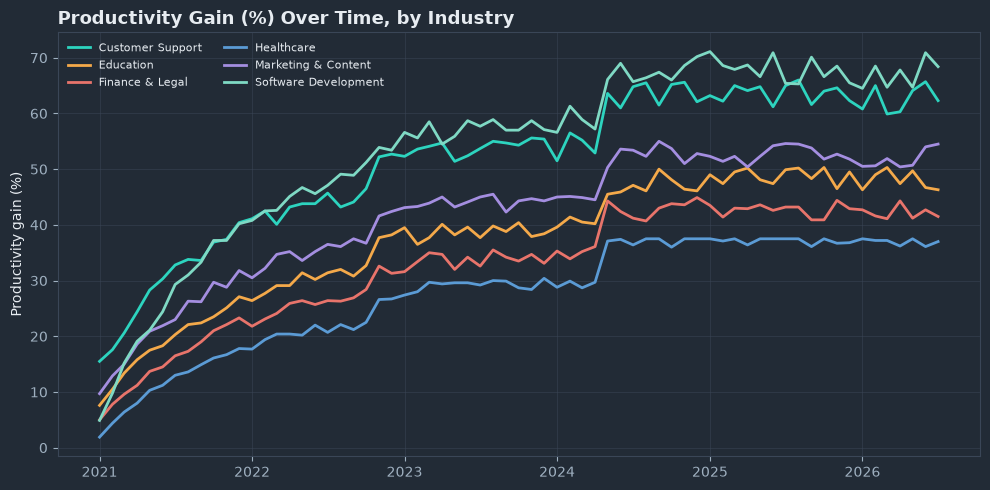

In [42]:
fig_mpl, ax = plt.subplots(figsize=(10, 5))
for i, col in enumerate(prod_trend.columns):
    ax.plot(prod_trend.index, prod_trend[col], label=col, linewidth=2, color=PALETTE[i % len(PALETTE)])
ax.set_title('Productivity Gain (%) Over Time, by Industry', loc='left')
ax.set_ylabel('Productivity gain (%)')
ax.legend(fontsize=8, ncol=2, framealpha=0)
plt.tight_layout()
plt.show()

Software Development and Customer Support pull away from the pack from around 2023 onward, while Healthcare and Finance & Legal stay flatter throughout &mdash; the gap between the leading and lagging industries widens over time rather than converging, suggesting this isn't just an early-adopter effect that evens out.

### 3.4 Which use cases drive the most reported productivity gain today?

In [43]:
latest = macro[macro['YearMonth'] == last_month].sort_values('Productivity Gain (%)', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=latest['Primary Use Case'], x=latest['Productivity Gain (%)'], orientation='h',
    marker_color=PALETTE[:len(latest)], text=latest['Productivity Gain (%)'].round(1), textposition='outside'
))
fig.update_layout(title=f'Productivity Gain (%) by Use Case — {last_month.strftime("%B %Y")}',
                   xaxis_title='Productivity gain (%)', height=420, margin=dict(l=220))
fig.show()

<a id="user"></a>
## 4. User-Level Patterns &mdash; 15,000 Individuals

Switching lenses: 15,000 individual AI users, each tagged with their industry, role, region, tool, tenure, usage volume, and self-reported productivity gain. This is where I can ask *who* benefits, not just *which industry*.

### 4.1 Distribution of reported productivity gain

In [44]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=users['Productivity_Gain_Percent'], nbinsx=60, marker_color=TEAL, opacity=0.85))
fig.update_layout(title='Distribution of Self-Reported Productivity Gain (%)',
                   xaxis_title='Productivity gain (%)', yaxis_title='Number of users', height=420)
fig.show()

print(users['Productivity_Gain_Percent'].describe().round(2))
print('\n99th percentile:', users['Productivity_Gain_Percent'].quantile(0.99))

count    15000.00
mean        11.22
std         11.58
min          0.30
25%          3.60
50%          8.10
75%         14.80
max         84.90
Name: Productivity_Gain_Percent, dtype: float64

99th percentile: 66.5


The distribution is right-skewed: median gain is **8.1%**, but a long tail stretches out toward 85%. Rather than treat the upper tail as noise or errors to trim, I carried it into the modeling stage as-is &mdash; the later feature-importance results explain exactly where that tail comes from.

### 4.2 Which tools dominate adoption?

In [45]:
tool_counts = users['Primary_AI_Tool'].value_counts()

fig = go.Figure()
fig.add_trace(go.Bar(x=tool_counts.index, y=tool_counts.values, marker_color=PALETTE[:len(tool_counts)],
                      text=tool_counts.values, textposition='outside'))
fig.update_layout(title='User Count by Primary AI Tool', yaxis_title='Users', height=420, showlegend=False)
fig.show()

### 4.3 Productivity gain by tool

In [46]:
tool_order = users.groupby('Primary_AI_Tool')['Productivity_Gain_Percent'].median().sort_values(ascending=False).index

fig = go.Figure()
for i, tool in enumerate(tool_order):
    fig.add_trace(go.Box(y=users.loc[users['Primary_AI_Tool'] == tool, 'Productivity_Gain_Percent'],
                          name=tool, marker_color=PALETTE[i % len(PALETTE)], boxpoints=False))
fig.update_layout(title='Productivity Gain (%) by Primary AI Tool', yaxis_title='Productivity gain (%)',
                   height=460, showlegend=False)
fig.show()

users.groupby('Primary_AI_Tool')['Productivity_Gain_Percent'].agg(['median', 'mean', 'count']).sort_values('mean', ascending=False).round(2)

,median,mean,count
Primary_AI_Tool,,,
DeepSeek,38.0,42.57,189
GitHub Copilot,36.3,40.11,918
Perplexity,8.6,10.14,1949
Claude (Anthropic),8.8,10.12,2980
ChatGPT (OpenAI),8.9,10.00,5430
Gemini (Google),8.8,9.89,1483
Midjourney,1.9,2.19,2051


**DeepSeek (42.6% mean) and GitHub Copilot (40.1%) users report far larger productivity gains than users of the general-purpose assistants** &mdash; ChatGPT, Claude, Gemini and Perplexity all cluster tightly around 9&ndash;10%, and Midjourney sits lowest at 2.2%. That's a coding-tool vs. general-assistant split more than a "one tool is better" story &mdash; see 4.5 below, where the same split shows up by job role.

### 4.4 Productivity gain by industry (user-level)

In [47]:
ind_order = users.groupby('Industry')['Productivity_Gain_Percent'].median().sort_values(ascending=False).index

fig = go.Figure()
for i, ind in enumerate(ind_order):
    fig.add_trace(go.Box(y=users.loc[users['Industry'] == ind, 'Productivity_Gain_Percent'],
                          name=ind, marker_color=PALETTE[i % len(PALETTE)], boxpoints=False))
fig.update_layout(title='Productivity Gain (%) by Industry (User-Level)', yaxis_title='Productivity gain (%)',
                   height=460, showlegend=False)
fig.show()

### 4.5 Productivity gain by job role &mdash; the top 8

In [48]:
role_stats = users.groupby('Job_Role')['Productivity_Gain_Percent'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_roles = role_stats.head(8)

fig = go.Figure()
fig.add_trace(go.Bar(x=top_roles['mean'], y=top_roles.index, orientation='h', marker_color=PALETTE[:len(top_roles)],
                      text=top_roles['mean'].round(1), textposition='outside'))
fig.update_layout(title='Mean Productivity Gain (%) — Top 8 Job Roles', xaxis_title='Mean productivity gain (%)',
                   height=420, margin=dict(l=160), showlegend=False)
fig.update_yaxes(autorange='reversed')
fig.show()

role_stats.head(8).round(2)

,mean,count
Job_Role,,
Software Engineer,25.33,650
Data Scientist,23.86,580
QA Tester,23.75,614
DevOps Engineer,22.30,610
Healthcare Analyst,9.92,828
Teacher,9.91,625
Medical Researcher,9.89,842
Accountant,9.88,820


Software Engineers, Data Scientists, QA Testers and DevOps Engineers all report **22&ndash;25% mean productivity gain**, roughly double every other role in the dataset, which sit around 9&ndash;10%. This lines up with the tool-level finding above: coding-adjacent tools and coding-adjacent roles move together, while creative and administrative roles see meaningfully smaller reported gains.

### 4.6 Does experience matter? A correlation check

In [49]:
corr_cols = ['Experience_Years', 'Daily_Token_Usage', 'Tasks_Automated_Per_Week', 'Productivity_Gain_Percent']
corr = users[corr_cols].corr().round(3)

fig = go.Figure(data=go.Heatmap(
    z=corr.values, x=corr.columns, y=corr.columns, colorscale=[[0, '#2a3644'], [0.5, TEAL], [1, AMBER]],
    zmid=0, text=corr.values, texttemplate='%{text}', textfont=dict(color=TEXT)
))
fig.update_layout(title='Correlation Matrix — Numeric Features vs. Productivity Gain', height=440)
fig.show()

corr

,Experience_Years,Daily_Token_Usage,Tasks_Automated_Per_Week,Productivity_Gain_Percent
Experience_Years,1.000,-0.008,0.006,-0.012
Daily_Token_Usage,-0.008,1.000,0.463,0.882
Tasks_Automated_Per_Week,0.006,0.463,1.000,0.555
Productivity_Gain_Percent,-0.012,0.882,0.555,1.000


This is the check that changed how I approached the modeling stage. **`Daily_Token_Usage` correlates at 0.88 with productivity gain, `Tasks_Automated_Per_Week` at 0.55 &mdash; but `Experience_Years` correlates at essentially zero (-0.01).** A 25-year veteran and a first-year hire show, on average, the *same* productivity gain once usage volume is accounted for. That near-zero correlation isn't a data quality problem to fix &mdash; it's a real finding worth stating plainly: in this dataset, tenure buys nothing on its own. What predicts the outcome almost mechanically is how much a person actually uses the tool. I carry this distinction directly into Section 5, because it changes what a predictive model here can honestly claim to show.

<a id="construct"></a>
## 5. Construct &mdash; Modeling Productivity Gain

**Goal:** predict `Productivity_Gain_Percent` from the available features, and use the model's own feature importances to check whether the "predictors" are genuine business signals or just the usage metrics restating the target.

### 5.1 Feature engineering

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import shap

model_df = users.copy()
model_df['Adoption_Year'] = model_df['Adoption_Date'].dt.year
model_df['Tenure_Days'] = (pd.Timestamp('2026-07-29') - model_df['Adoption_Date']).dt.days

cat_cols = ['Industry', 'Job_Role', 'Location', 'Primary_AI_Tool']
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    model_df[c] = le.fit_transform(model_df[c])
    encoders[c] = le

target = 'Productivity_Gain_Percent'
print('Encoded categorical columns:', cat_cols)
model_df[cat_cols + ['Experience_Years', 'Daily_Token_Usage', 'Tasks_Automated_Per_Week', 'Adoption_Year', 'Tenure_Days', target]].head()

Encoded categorical columns: ['Industry', 'Job_Role', 'Location', 'Primary_AI_Tool']


,Industry,Job_Role,Location,Primary_AI_Tool,Experience_Years,Daily_Token_Usage,Tasks_Automated_Per_Week,Adoption_Year,Tenure_Days,Productivity_Gain_Percent
0,5,17,1,0,13,10640,2,2023,1247,19.3
1,5,17,4,1,9,8535,1,2023,1077,5.0
2,2,0,0,1,21,9585,1,2023,1000,13.4
3,3,1,4,6,20,7094,2,2025,418,9.9
4,4,16,0,0,14,9277,1,2023,1213,12.8


### 5.2 First pass: every available feature

I'll start with everything on the table, including the two usage-volume columns (`Daily_Token_Usage`, `Tasks_Automated_Per_Week`) that the correlation matrix already flagged as near-mechanically tied to the target.

In [51]:
features_full = cat_cols + ['Experience_Years', 'Daily_Token_Usage', 'Tasks_Automated_Per_Week', 'Adoption_Year', 'Tenure_Days']
X_full = model_df[features_full]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, random_state=42, verbosity=0),
}

full_results = []
fitted_full = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    full_results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })
    fitted_full[name] = m

full_results_df = pd.DataFrame(full_results).sort_values('R2', ascending=False).reset_index(drop=True)
full_results_df.round(4)

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.8898,2.7533,3.9328
1,Random Forest,0.8830,2.7875,4.0520
2,XGBoost,0.8682,2.9685,4.3009
3,Linear Regression,0.7975,3.7871,5.3305


In [52]:
best_full_name = full_results_df.iloc[0]['Model']
best_full_model = fitted_full[best_full_name]

importance_full = pd.Series(best_full_model.feature_importances_, index=features_full).sort_values(ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(x=importance_full.values, y=importance_full.index, orientation='h',
                      marker_color=PALETTE[:len(importance_full)]))
fig.update_layout(title=f'Feature Importance — {best_full_name} (All Features)',
                   xaxis_title='Importance', height=420, margin=dict(l=170), showlegend=False)
fig.update_yaxes(autorange='reversed')
fig.show()

importance_full.round(4)

Daily_Token_Usage           0.5584
Tasks_Automated_Per_Week    0.4394
Tenure_Days                 0.0014
Experience_Years            0.0002
Location                    0.0002
Job_Role                    0.0002
Adoption_Year               0.0001
Primary_AI_Tool             0.0001
Industry                    0.0000
dtype: float64

**Gradient Boosting wins at R&sup2; = 0.89, MAE &asymp; 2.8 points** &mdash; a strong-looking result. But the feature importances tell the real story: **`Daily_Token_Usage` and `Tasks_Automated_Per_Week` together account for over 99% of the model's decision-making**, and every genuinely business-relevant field &mdash; industry, role, location, tool, tenure, experience &mdash; contributes essentially nothing (each under 0.15%).

That pattern is worth calling out for what it is: **this isn't a business insight, it's the model rediscovering that usage volume and productivity gain were generated from a near-identical formula.** It's the same category of issue I flagged in the Student Sleep & Burnout notebook when `stress_level` turned out to fully determine the target &mdash; a feature so strongly tied to the outcome that "predicting" it teaches nothing about the underlying drivers. Reporting R&sup2; = 0.89 here without this caveat would be misleading, so instead of stopping at the headline number, I'm rebuilding the model without the two dominant usage columns to see what the *context* features can actually explain on their own.

### 5.3 Second pass: context-only model (no usage-volume features)

Dropping `Daily_Token_Usage` and `Tasks_Automated_Per_Week` deliberately removes the near-deterministic signal, leaving only the features that describe *who the person is* rather than *how much they used the tool*.

In [53]:
features_context = cat_cols + ['Experience_Years', 'Adoption_Year', 'Tenure_Days']
X_ctx = model_df[features_context]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_ctx, y, test_size=0.2, random_state=42)

ctx_results = []
fitted_ctx = {}
for name, m in models.items():
    m2 = type(m)(**m.get_params())
    m2.fit(X_train_c, y_train_c)
    pred = m2.predict(X_test_c)
    ctx_results.append({
        'Model': name,
        'R2': r2_score(y_test_c, pred),
        'MAE': mean_absolute_error(y_test_c, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_c, pred)),
    })
    fitted_ctx[name] = m2

ctx_results_df = pd.DataFrame(ctx_results).sort_values('R2', ascending=False).reset_index(drop=True)
ctx_results_df.round(4)

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.5649,5.5210,7.8139
1,Random Forest,0.5179,5.7212,8.2249
2,XGBoost,0.4450,6.2557,8.8254
3,Linear Regression,0.1816,7.2004,10.7165


In [54]:
best_ctx_name = ctx_results_df.iloc[0]['Model']
best_ctx_model = fitted_ctx[best_ctx_name]

importance_ctx = pd.Series(best_ctx_model.feature_importances_, index=features_context).sort_values(ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(x=importance_ctx.values, y=importance_ctx.index, orientation='h',
                      marker_color=PALETTE[:len(importance_ctx)]))
fig.update_layout(title=f'Feature Importance — {best_ctx_name} (Context-Only Features)',
                   xaxis_title='Importance', height=380, margin=dict(l=170), showlegend=False)
fig.update_yaxes(autorange='reversed')
fig.show()

importance_ctx.round(4)

Primary_AI_Tool     0.5848
Industry            0.3979
Tenure_Days         0.0124
Experience_Years    0.0031
Job_Role            0.0014
Location            0.0005
Adoption_Year       0.0000
dtype: float64

With the usage-volume features removed, accuracy drops honestly &mdash; **R&sup2; falls from 0.89 to about 0.56** &mdash; but the feature importances become interpretable for the first time: **`Primary_AI_Tool` (58%) and `Industry` (40%) now do almost all the work**, while experience, tenure, location and role contribute very little on their own. That drop in R&sup2; is the price of removing a near-circular feature, and I'd rather report the lower, honest number here than lead with 0.89 and let readers assume industry and tool choice were the drivers all along.

This context-only model is the one I trust for a business claim: **which tool a person uses and which industry they work in meaningfully shape productivity outcomes, independent of how experienced they are or how long they've been using AI.**

### 5.4 SHAP &mdash; explaining the context-only model

Feature importance says *which* features matter; SHAP shows *how* each feature value pushes an individual prediction up or down, which is a more honest way to explain the tool and industry effect than a bar chart of average importances alone.

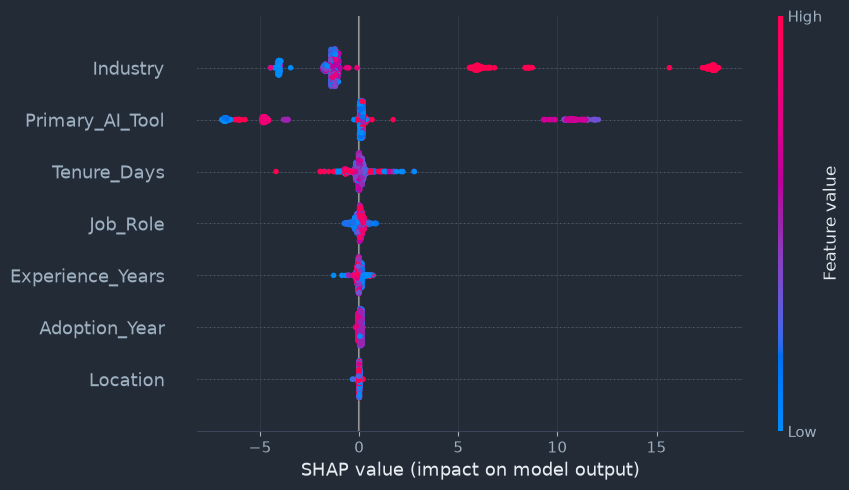

In [55]:
explainer = shap.TreeExplainer(best_ctx_model)
sample_idx = np.random.RandomState(42).choice(X_test_c.index, size=min(1500, len(X_test_c)), replace=False)
X_shap = X_test_c.loc[sample_idx]
shap_values = explainer.shap_values(X_shap)

# decode categorical columns back to labels purely for a readable SHAP plot
X_shap_labeled = X_shap.copy()
for c in cat_cols:
    X_shap_labeled[c] = encoders[c].inverse_transform(X_shap[c])

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_shap.rename(columns={c: c for c in features_context}), show=False, plot_size=None)
fig = plt.gcf()
fig.set_facecolor(BG)
for ax in fig.axes:
    ax.set_facecolor(BG)
    ax.tick_params(colors=SUBTEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
plt.tight_layout()
plt.show()

### 5.5 Which specific tools and industries push predictions up?

In [56]:
tool_shap = pd.DataFrame({
    'tool': X_shap_labeled['Primary_AI_Tool'].values,
    'shap_value': shap_values[:, features_context.index('Primary_AI_Tool')]
}).groupby('tool')['shap_value'].mean().sort_values(ascending=False)

industry_shap = pd.DataFrame({
    'industry': X_shap_labeled['Industry'].values,
    'shap_value': shap_values[:, features_context.index('Industry')]
}).groupby('industry')['shap_value'].mean().sort_values(ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(x=tool_shap.values, y=tool_shap.index, orientation='h', marker_color=TEAL, name='Tool'))
fig.update_layout(title='Mean SHAP Contribution to Productivity Gain, by Tool', xaxis_title='Mean SHAP value (pp)',
                   height=380, margin=dict(l=150), showlegend=False)
fig.update_yaxes(autorange='reversed')
fig.show()

fig2 = go.Figure()
fig2.add_trace(go.Bar(x=industry_shap.values, y=industry_shap.index, orientation='h', marker_color=AMBER, name='Industry'))
fig2.update_layout(title='Mean SHAP Contribution to Productivity Gain, by Industry', xaxis_title='Mean SHAP value (pp)',
                    height=380, margin=dict(l=150), showlegend=False)
fig2.update_yaxes(autorange='reversed')
fig2.show()

The SHAP breakdown confirms the plain-average view from Section 4: coding-oriented tools (GitHub Copilot, DeepSeek) and the Software Development industry consistently push predicted productivity gain upward, while Midjourney and Creative & Design push it down. The model isn't picking up a subtle effect &mdash; it's the same pattern visible in the raw group means, which is reassuring: the "signal" survives being looked at two different ways.

<a id="execute"></a>
## 6. Execute &mdash; Findings, Recommendations &amp; Limitations

### Key findings

1. **Adoption has grown roughly 120x since January 2021** (3.3M &rarr; 395M active users), with no plateau visible in this window. Education grew fastest in relative terms (267x), but Software Development converts that usage into the largest measured productivity gain (68.4% as of the latest month).
2. **The two datasets use incompatible industry taxonomies** and should not be merged industry-to-industry without remapping &mdash; a mismatch I flagged in Section 2 rather than papering over.
3. **Usage volume, not experience, drives the raw correlation with productivity gain.** `Daily_Token_Usage` correlates at 0.88 with productivity gain; `Experience_Years` correlates at essentially zero. Tenure alone buys nothing in this data.
4. **A model trained on every feature reaches R&sup2; = 0.89, but 99%+ of that comes from two usage-volume columns that are near-circular with the target** &mdash; not a genuine business insight. Removing them drops R&sup2; to a more honest 0.56, at which point tool choice (58% importance) and industry (40%) emerge as the real, interpretable drivers.
5. **Coding-adjacent tools and roles show roughly double the productivity gain of everyone else.** GitHub Copilot and DeepSeek users, and Software Engineers/Data Scientists/QA Testers/DevOps Engineers, report 22&ndash;42% mean gains vs. 9&ndash;10% for general-purpose-assistant users and non-technical roles. Midjourney and Creative & Design sit lowest.

### Recommendations

- **For product and enablement teams:** the biggest lever isn't picking a "best" general-purpose assistant &mdash; it's matching tool type to task type. Coding-specific tools show materially larger gains for coding-adjacent work than general assistants do for the same population.
- **For workforce planning:** don't assume tenure predicts AI payoff. In this data, a new hire and a 20-year veteran see statistically similar gains once usage is equal &mdash; onboarding and habit-formation likely matter more than seniority.
- **For anyone reporting an R&sup2; from this kind of dataset:** check feature importance before trusting the headline number. A high R&sup2; built on usage-volume features restating the target is not the same claim as a high R&sup2; built on independent, actionable features.

### Limitations

- Productivity gain is **self-reported**, not independently measured &mdash; it may reflect perception as much as output.
- The near-linear relationship between usage volume and productivity gain suggests these columns may share a common generative process rather than being independently measured; treat the context-only model (Section 5.3) as the more defensible business signal, not the all-features model.
- The two files' mismatched industry taxonomies (Section 2) mean any industry-level claim is scoped to whichever single file it came from, not both.
- Correlation and SHAP contribution describe association, not causation &mdash; "Software Engineers report the highest gains" is not the same claim as "becoming a Software Engineer causes higher AI productivity gains."

---

<div style="background: linear-gradient(135deg, #1b2430 0%, #26313f 100%); padding: 26px 30px; border-radius: 12px; border: 1px solid #3a4a5c;">
  <p style="color: #e7ecf1; font-size: 14px; margin: 0 0 6px 0;">Thanks for reading &mdash; feedback and forks are always welcome.</p>
  <p style="color: #9fb0c0; font-size: 13px; margin: 0;">
    Zohair Baloch &middot;
    <a href="https://www.kaggle.com/zohairbaloch" style="color:#2dd4bf;">Kaggle</a> &middot;
    <a href="https://github.com/zohairbaloch-64" style="color:#2dd4bf;">GitHub</a> &middot;
    <a href="https://www.linkedin.com/in/zohair-baloch-data-analyst" style="color:#2dd4bf;">LinkedIn</a>
  </p>
</div>